# Klasifikasi Aksara Nusantara Menggunakan Deep Learning Berbasis EfficientNet
**Dataset**: Aksara Jawa, Bali, dan Sunda

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


### 1. Persiapan Dataset
Mengekstrak path file dan label dari struktur folder. Label digabungkan dari nama aksara dan karakternya (misal: 'Aksara Bali_ba').

In [ ]:
#Ekstrak Zip Dataset (Jika Running Di Google Collab)
!unzip -q /content/Dataset.zip -d /content

In [3]:
dataset_dir = '/content/Dataset'

filepaths = []
labels = []

for script_dir in os.listdir(dataset_dir):
    script_path = os.path.join(dataset_dir, script_dir)
    if os.path.isdir(script_path):
        for char_dir in os.listdir(script_path):
            char_path = os.path.join(script_path, char_dir)
            if os.path.isdir(char_path):
                # Ambil semua file gambar di dalam folder karakter
                for img_path in glob.glob(os.path.join(char_path, '*.*')):
                    filepaths.append(img_path)
                    labels.append(f"{script_dir}_{char_dir}")

# Buat DataFrame
df = pd.DataFrame({'filepath': filepaths, 'label': labels})
print(f"Total gambar: {len(df)}")
print(f"Total kelas: {df['label'].nunique()}")
df.head()

Total gambar: 16979
Total kelas: 68


,filepath,label
0,/content/Dataset/Aksara Sunda/na/label_na_1724...,Aksara Sunda_na
1,/content/Dataset/Aksara Sunda/na/label_na_1724...,Aksara Sunda_na
2,/content/Dataset/Aksara Sunda/na/label_na_1724...,Aksara Sunda_na
3,/content/Dataset/Aksara Sunda/na/label_na_1724...,Aksara Sunda_na
4,/content/Dataset/Aksara Sunda/na/label_na_1724...,Aksara Sunda_na


### 2. Pembagian Data (Train & Validation)
Membagi data menjadi data latih (80%) dan data validasi (20%).

In [4]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

print(f"Jumlah data latih: {len(train_df)}")
print(f"Jumlah data validasi: {len(val_df)}")

Jumlah data latih: 13583
Jumlah data validasi: 3396


### 3. Data Generator
Dataset sudah teraugmentasi. Tidak diperlukan rescaling karena EfficientNetB0 sudah otomatis melakukan normalisasi pada input gambar secara internal.

In [5]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 13583 validated image filenames belonging to 68 classes.
Found 3396 validated image filenames belonging to 68 classes.


### 4. Membangun Model Berbasis EfficientNetB0

In [6]:
num_classes = df['label'].nunique()

# Load pre-trained EfficientNetB0 tanpa classification head (include_top=False)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model (Feature Extractor)
base_model.trainable = False

# Tambahkan custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,394,983 (16.77 MB)

 Trainable params: 345,412 (1.32 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 5. Callbacks

In [7]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('best_model_efficientnet.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

### 6. Proses Training Tahap Awal
Melatih head classification (layer baru) yang ditambahkan di atas pre-trained model.

In [8]:
EPOCHS = 20

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3430 - loss: 2.5541
Epoch 1: val_accuracy improved from None to 0.86396, saving model to best_model_efficientnet.keras

Epoch 1: finished saving model to best_model_efficientnet.keras
425/425 ━━━━━━━━━━━━━━━━━━━━ 100s 162ms/step - accuracy: 0.5310 - loss: 1.6821 - val_accuracy: 0.8640 - val_loss: 0.5252 - learning_rate: 0.0010
Epoch 2/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7777 - loss: 0.7033
Epoch 2: val_accuracy improved from 0.86396 to 0.93375, saving model to best_model_efficientnet.keras

Epoch 2: finished saving model to best_model_efficientnet.keras
425/425 ━━━━━━━━━━━━━━━━━━━━ 32s 74ms/step - accuracy: 0.7926 - loss: 0.6497 - val_accuracy: 0.9337 - val_loss: 0.2736 - learning_rate: 0.0010
Epoch 3/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8488 - loss: 0.4697
Epoch 3: val_accuracy improved from 0.93375 to 0.95760, saving model to best_model_efficientnet.keras

Epoch 3: finishe

### 7. Fine Tuning Model
Membuka beberapa layer akhir dari base model dan melatih ulang dengan learning rate yang lebih kecil untuk meningkatkan akurasi secara signifikan.

In [9]:
base_model.trainable = True

# Freeze semua layer kecuali 20 layer terakhir
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Compile ulang dengan learning rate yang lebih kecil
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
424/425 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6608 - loss: 1.3779
Epoch 1: val_accuracy did not improve from 0.98704
425/425 ━━━━━━━━━━━━━━━━━━━━ 85s 134ms/step - accuracy: 0.7186 - loss: 1.0554 - val_accuracy: 0.9426 - val_loss: 0.2019 - learning_rate: 1.0000e-05
Epoch 2/15
424/425 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8111 - loss: 0.6362
Epoch 2: val_accuracy did not improve from 0.98704
425/425 ━━━━━━━━━━━━━━━━━━━━ 31s 72ms/step - accuracy: 0.8259 - loss: 0.5634 - val_accuracy: 0.9567 - val_loss: 0.1459 - learning_rate: 1.0000e-05
Epoch 3/15
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8516 - loss: 0.4534
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_accuracy did not improve from 0.98704
425/425 ━━━━━━━━━━━━━━━━━━━━ 31s 74ms/step - accuracy: 0.8595 - loss: 0.4293 - val_accuracy: 0.9691 - val_loss: 0.1149 - learning_rate: 1.0000e-05
Epoch 4/15
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.

### 8. Evaluasi Model (Visualisasi Loss & Akurasi)
Menggabungkan riwayat training tahap awal dan tahap fine tuning untuk melihat progres secara menyeluruh.

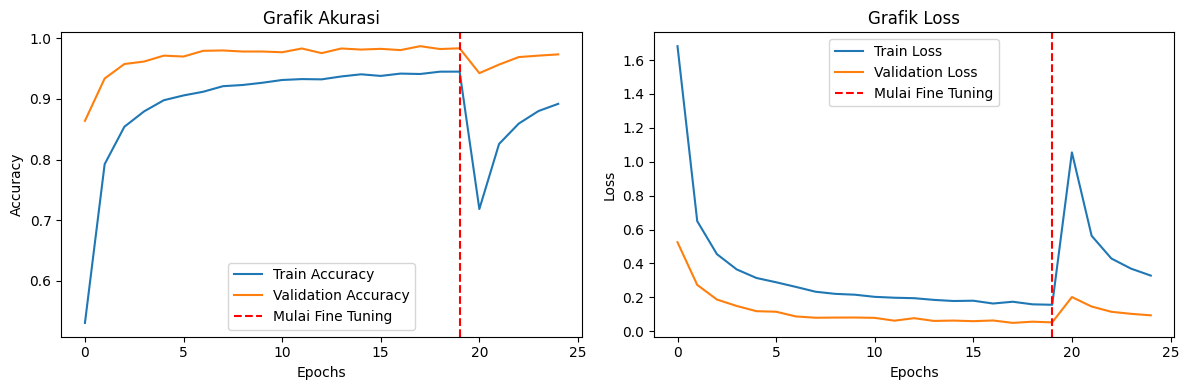

In [10]:
acc = history.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss = history.history['loss'] + history_finetune.history['loss']
val_loss = history.history['val_loss'] + history_finetune.history['val_loss']

plt.figure(figsize=(12, 4))

# Akurasi
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=len(history.history['accuracy'])-1, color='r', linestyle='--', label='Mulai Fine Tuning')
plt.title('Grafik Akurasi')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(x=len(history.history['loss'])-1, color='r', linestyle='--', label='Mulai Fine Tuning')
plt.title('Grafik Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### 9. Confusion Matrix & Classification Report
Evaluasi metrik prediksi menggunakan model terbaik hasil akhir dari proses fine-tuning.

107/107 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step
Classification Report:

                  precision    recall  f1-score   support

  Aksara Bali_ba       1.00      0.70      0.82        50
  Aksara Bali_ca       0.74      0.68      0.71        50
  Aksara Bali_da       1.00      0.86      0.92        50
  Aksara Bali_ga       0.88      0.88      0.88        51
  Aksara Bali_ha       0.80      0.92      0.85        48
  Aksara Bali_ja       0.96      0.81      0.88        53
  Aksara Bali_ka       0.82      1.00      0.90        51
  Aksara Bali_la       0.88      0.71      0.79        52
  Aksara Bali_ma       0.94      0.88      0.91        51
  Aksara Bali_na       0.95      0.84      0.89        50
 Aksara Bali_nga       0.90      0.90      0.90        50
 Aksara Bali_nya       0.76      0.96      0.85        54
  Aksara Bali_pa       0.82      0.90      0.86        51
  Aksara Bali_ra       0.86      0.96      0.91        50
  Aksara Bali_sa       0.84      0.80      0.82        51
  A

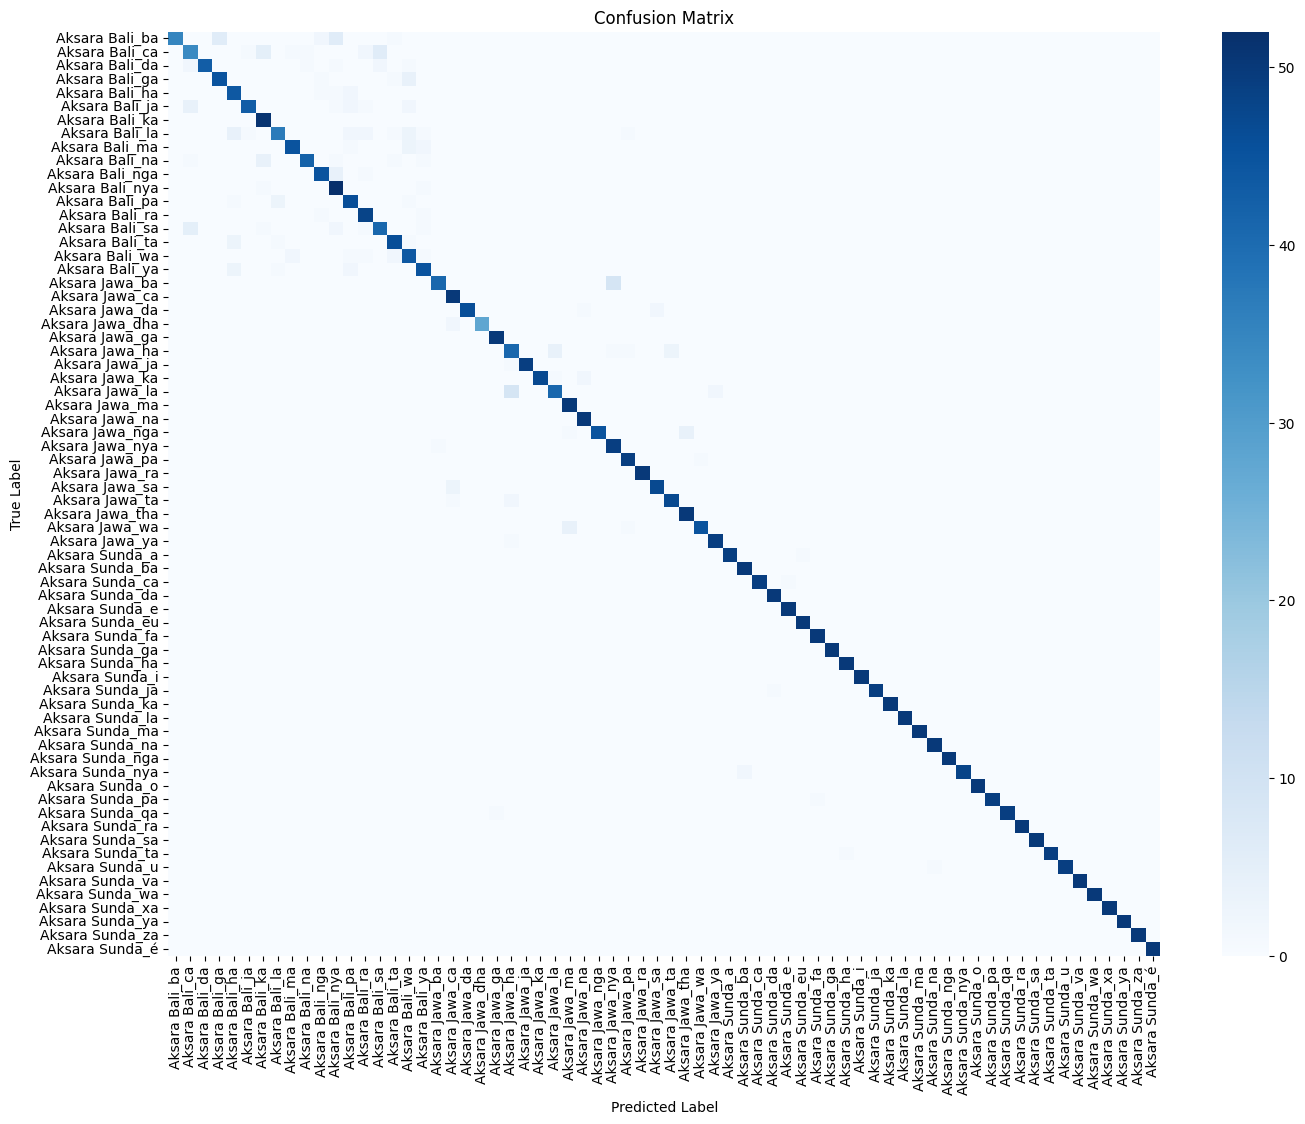

In [11]:
val_generator.reset()
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()